In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 2 (Jun 2023 - May 2024)\Load_hourly\48190948_Loads_hourly.csv"
df = pd.read_csv(path)

In [3]:
df.head()

,Timestamp,Plug_Basement,Cooling,Exhaust fan,EHW,Sumppump,Emergency light load,EL,Fire alarm,Heat pump electric,...,Plug3,PV_meter1_load (kW),PV_meter2_load (kW),Battery cabinet,Solar_hot_water_load (kW),Solar rapid shutdown,Control,NET,IN,OUT
0,2023-06-01 00:00:00-04:00,0.060557,0.079349,0.004065,0.00000,0.001167,0.048765,0.108641,0.066298,0.0,...,0.001106,0.0,0.0,0.003108,0.0,0.003981,0.170596,1.274129,1.274129,0.0
1,2023-06-01 01:00:00-04:00,0.092682,0.190846,0.004040,0.00000,0.001164,0.048407,0.108183,0.066528,0.0,...,0.001105,0.0,0.0,0.003135,0.0,0.003870,0.200758,1.453944,1.453944,0.0
2,2023-06-01 02:00:00-04:00,0.101246,0.190826,0.004022,0.00000,0.001161,0.048290,0.108065,0.066141,0.0,...,0.001111,0.0,0.0,0.003102,0.0,0.003880,0.202078,1.448363,1.448363,0.0
3,2023-06-01 03:00:00-04:00,0.055301,0.190585,0.004046,0.00000,0.001174,0.048419,0.108362,0.065712,0.0,...,0.001111,0.0,0.0,0.003107,0.0,0.003935,0.202259,1.398009,1.398009,0.0
4,2023-06-01 04:00:00-04:00,0.107533,0.190497,0.004023,0.16568,0.001167,0.048289,0.108168,0.066343,0.0,...,0.001105,0.0,0.0,0.003119,0.0,0.003871,0.201630,1.616125,1.616125,0.0


In [4]:
df.describe()

,Plug_Basement,Cooling,Exhaust fan,EHW,Sumppump,Emergency light load,EL,Fire alarm,Heat pump electric,Heating,...,Plug3,PV_meter1_load (kW),PV_meter2_load (kW),Battery cabinet,Solar_hot_water_load (kW),Solar rapid shutdown,Control,NET,IN,OUT
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8.784000e+03,8784.000000,...,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,0.103698,0.029474,0.003933,0.029946,0.001117,0.048298,0.007808,0.067537,1.901184e-11,0.296547,...,0.005247,0.977056,0.691936,0.003005,0.003643,0.004066,0.154556,-0.162775,0.956148,-1.118951
std,0.074984,0.067345,0.000083,0.090486,0.000036,0.002710,0.028106,0.002752,1.781847e-09,0.384552,...,0.015620,1.514704,1.257576,0.000123,0.011753,0.000134,0.025282,2.659883,0.754010,2.098852
min,0.049654,0.000000,0.003659,-0.000008,0.000956,0.042864,0.000000,0.061351,0.000000e+00,0.000000,...,0.000898,-0.041345,-0.036197,0.002811,0.000000,0.003709,0.123873,-10.087262,0.000000,-10.087262
25%,0.075696,0.000000,0.003871,0.000000,0.001093,0.047205,0.000000,0.066329,0.000000e+00,0.000000,...,0.000974,0.000000,0.000000,0.002852,0.000000,0.003976,0.131647,-1.268012,0.037065,-1.337814
50%,0.092378,0.000000,0.003932,0.000000,0.001118,0.047860,0.000000,0.067121,0.000000e+00,0.032197,...,0.000993,0.000000,0.000000,0.003093,0.000000,0.004052,0.151629,1.084698,1.084879,0.000000
75%,0.105888,0.001918,0.003992,0.000000,0.001142,0.048561,0.000000,0.067899,0.000000e+00,0.692251,...,0.001109,1.614774,0.861809,0.003104,0.000000,0.004136,0.165178,1.664570,1.664570,0.000000
max,1.095967,0.191451,0.004164,1.224976,0.001234,0.079436,0.123930,0.087855,1.670000e-07,1.953696,...,0.161776,8.445168,5.658001,0.003164,0.052082,0.004709,0.210949,3.016634,3.016634,0.000000


In [5]:
df.isna().sum()

Timestamp                    0
Plug_Basement                0
Cooling                      0
Exhaust fan                  0
EHW                          0
Sumppump                     0
Emergency light load         0
EL                           0
Fire alarm                   0
Heat pump electric           0
Heating                      0
IT                           0
Lighting                     0
Plug1                        0
Plug2                        0
Plug3                        0
PV_meter1_load (kW)          0
PV_meter2_load (kW)          0
Battery cabinet              0
Solar_hot_water_load (kW)    0
Solar rapid shutdown         0
Control                      0
NET                          0
IN                           0
OUT                          0
dtype: int64

In [6]:
num = df.select_dtypes(include='number')
zero_counts = (num == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(2)
zeros_summary = pd.concat([zero_counts.rename('zero_count'), zero_pct.rename('zero_pct')], axis=1).sort_values('zero_count', ascending=False)
zeros_summary

,zero_count,zero_pct
Heat pump electric,8783,99.99
EL,8101,92.22
EHW,7764,88.39
Solar_hot_water_load (kW),7336,83.52
OUT,5386,61.32
PV_meter2_load (kW),5163,58.78
Cooling,5004,56.97
PV_meter1_load (kW),4165,47.42
Heating,3765,42.86
IN,1815,20.66


In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_21212\330094659.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [11]:
df= df.drop(columns=['Heat pump electric'])
sorted(df.columns)

['Battery cabinet',
 'Control',
 'Cooling',
 'EHW',
 'EL',
 'Emergency light load',
 'Exhaust fan',
 'Fire alarm',
 'Heating',
 'IN',
 'IT',
 'Lighting',
 'NET',
 'OUT',
 'PV_meter1_load (kW)',
 'PV_meter2_load (kW)',
 'Plug1',
 'Plug2',
 'Plug3',
 'Plug_Basement',
 'Solar rapid shutdown',
 'Solar_hot_water_load (kW)',
 'Sumppump']

In [12]:
df.corr()

,Plug_Basement,Cooling,Exhaust fan,EHW,Sumppump,Emergency light load,EL,Fire alarm,Heating,IT,...,Plug3,PV_meter1_load (kW),PV_meter2_load (kW),Battery cabinet,Solar_hot_water_load (kW),Solar rapid shutdown,Control,NET,IN,OUT
Plug_Basement,1.000000,0.138548,-0.030578,0.052314,-0.086726,-0.002687,0.169339,0.014357,-0.055421,-0.002708,...,-0.013722,0.179841,0.156239,-0.035965,0.064636,0.015411,0.118160,-0.139431,-0.085951,-0.145812
Cooling,0.138548,1.000000,-0.359510,0.060556,-0.270821,-0.220644,0.184386,-0.267972,-0.337538,-0.168730,...,0.334429,0.078698,0.163853,0.315548,-0.109753,-0.045455,0.799676,-0.131874,-0.118356,-0.124560
Exhaust fan,-0.030578,-0.359510,1.000000,-0.037626,0.901567,0.228137,-0.055808,0.429545,-0.200589,0.123255,...,-0.144529,0.048178,0.045430,-0.112890,0.119400,0.103821,-0.470120,-0.097030,-0.119710,-0.079955
EHW,0.052314,0.060556,-0.037626,1.000000,-0.039655,-0.024777,0.029427,-0.029333,0.042046,-0.038092,...,0.078568,0.127195,0.063557,0.041322,0.084213,0.006541,0.095839,-0.056517,-0.009515,-0.068192
Sumppump,-0.086726,-0.270821,0.901567,-0.039655,1.000000,0.229740,-0.052670,0.374596,-0.266460,0.078471,...,-0.092774,-0.005131,0.011238,0.021804,0.078789,0.084288,-0.418737,-0.061123,-0.111130,-0.037533
Emergency light load,-0.002687,-0.220644,0.228137,-0.024777,0.229740,1.000000,0.005849,0.147018,-0.042437,0.049183,...,-0.050031,-0.093170,-0.106646,-0.024465,-0.040537,0.036598,-0.225535,0.099054,0.061644,0.103356
EL,0.169339,0.184386,-0.055808,0.029427,-0.052670,0.005849,1.000000,-0.123428,-0.155876,-0.028664,...,-0.061215,0.055594,0.073939,0.066951,-0.018208,-0.047085,0.087397,-0.067177,-0.052063,-0.066410
Fire alarm,0.014357,-0.267972,0.429545,-0.029333,0.374596,0.147018,-0.123428,1.000000,0.007900,0.129544,...,-0.096992,-0.061981,-0.045179,-0.318035,0.029421,0.147024,-0.266649,0.046885,0.024970,0.050420
Heating,-0.055421,-0.337538,-0.200589,0.042046,-0.266460,-0.042437,-0.155876,0.007900,1.000000,-0.003510,...,-0.184360,-0.141455,-0.330572,-0.294555,-0.048374,-0.006762,0.179589,0.369801,0.540780,0.274312
IT,-0.002708,-0.168730,0.123255,-0.038092,0.078471,0.049183,-0.028664,0.129544,-0.003510,1.000000,...,-0.130754,0.011632,0.040649,-0.264911,0.060507,0.123140,-0.173400,-0.031031,0.013944,-0.044350


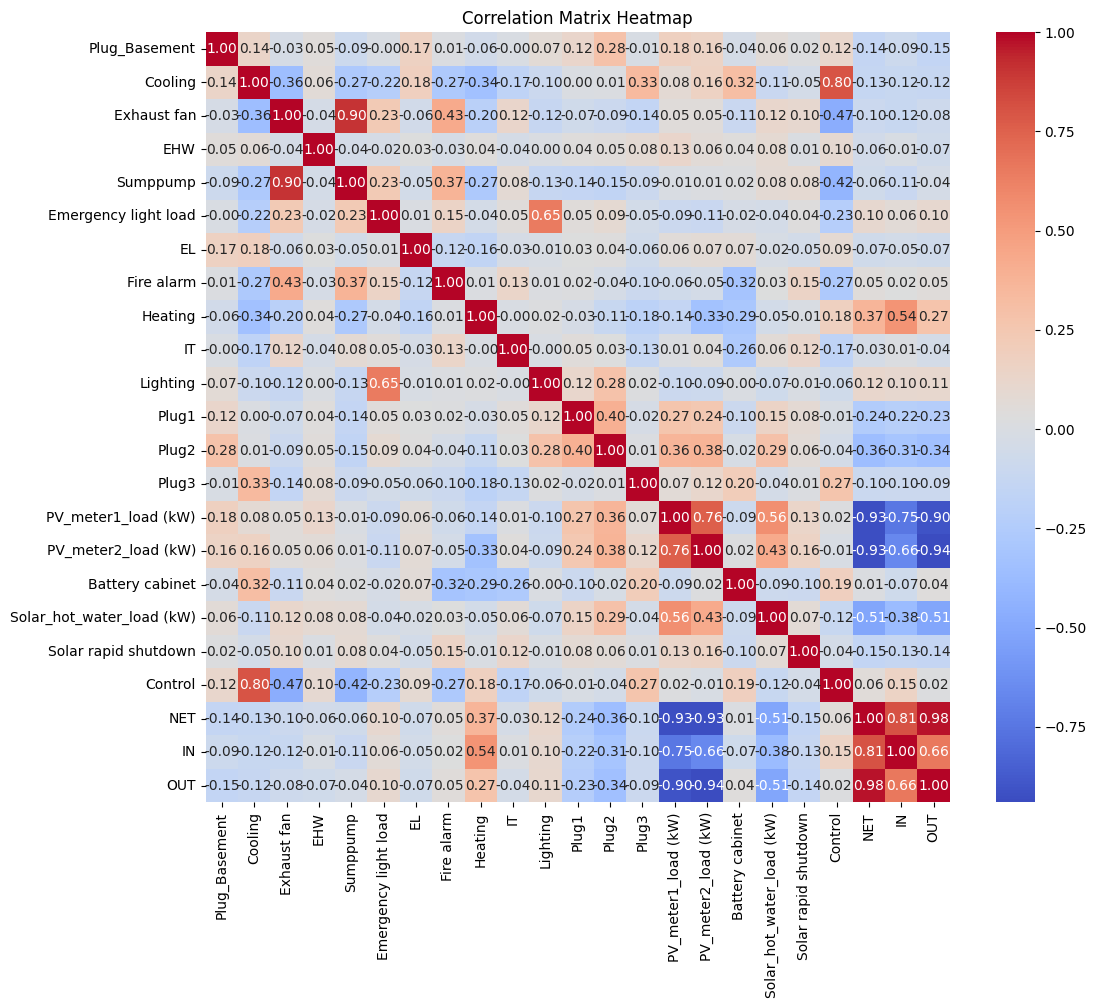

In [13]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

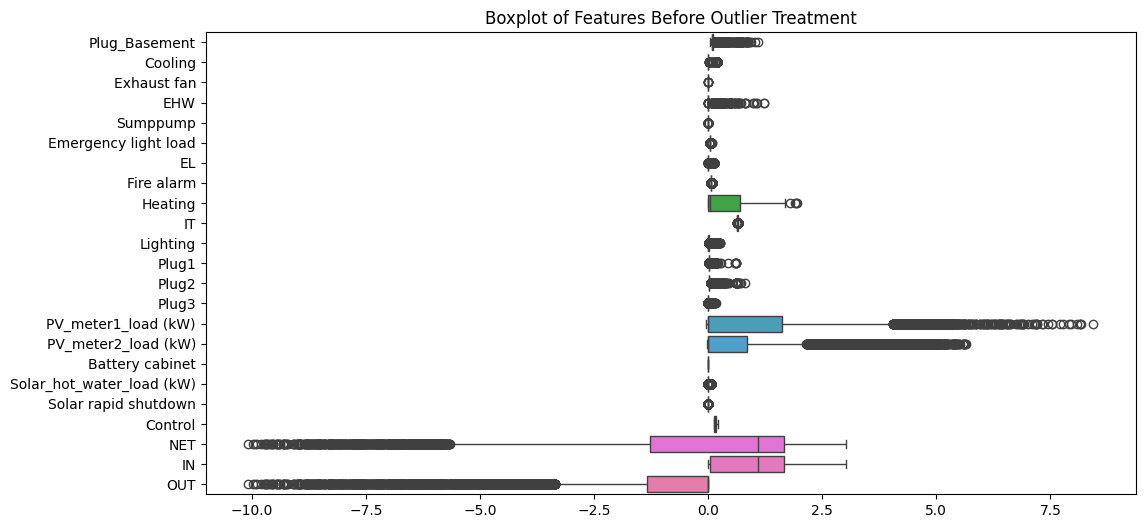

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, orient = 'h')
plt.title('Boxplot of Features Before Outlier Treatment')
plt.show()

In [ ]:
# def treat_outliers_iqr(df):
#     df_clean = df.copy()
#     for col in df_clean.columns:
#         Q1 = df_clean[col].quantile(0.25)
#         Q3 = df_clean[col].quantile(0.75)
#         IQR = Q3 - Q1


#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
#     return df_clean
# df = treat_outliers_iqr(df)
# df.shape

In [ ]:
# plt.figure(figsize=(12,6))
# sns.boxplot(data=df, orient = 'h')
# plt.title('Boxplot of Features After Outlier Treatment')
# plt.show()